# Fine-tuning de Qwen3.5-4B para Minimarket

Aplicación para construir un agente de atención por WhatsApp que debe conocer el catálogo real de
250 productos, el horario, los medios de pago y la política de devoluciones del dossier.

Evaluamos distintas combinaciones de hiperparámetros y dos formas de aplicar LoRA (solo en las capas de atención, o en atención + feed-forward), para entender qué combinación generaliza mejor
sin memorizar de más.

In [1]:
# 0) PyTorch para GPU Blackwell (RTX 50xx, sm_120).
# Blackwell necesita PyTorch >= 2.7 construido con CUDA >= 12.8. Tu driver (nvidia-smi)
# reporta soporte hasta CUDA 13.1, así que usamos el índice de ruedas cu130 (el mismo
# que documenta Unsloth para instalar en Windows con GPUs Blackwell).
#
# Va en su propia celda, ANTES de unsloth: así un `pip install unsloth` posterior no
# resuelve sin índice y termina trayendo un torch viejo (ej. cu121, sin soporte sm_120),
# que es justo el conflicto de versiones que tuviste antes.
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130


Looking in indexes: https://download.pytorch.org/whl/cu130


In [2]:
# En Colab (Linux + T4) "unsloth" resuelve solo sus dependencias sin problema.
# En Windows nativo con una GPU Blackwell (RTX 50xx) eso no alcanza: si dejamos que
# pip resuelva todo junto, puede pisar el torch cu130 que acabamos de instalar en la
# celda anterior. Por eso unsloth/unsloth_zoo se instalan con --no-deps.

# 1) Triton para Windows: el paquete oficial "triton" no publica ruedas para Windows;
#    sin este fork, Unsloth falla al importar sus kernels rápidos. Blackwell necesita
#    Triton >= 3.3 — dejamos que pip resuelva la versión más nueva, compatible con el
#    torch recién instalado.
!pip install --upgrade triton-windows

# 2) bitsandbytes >= 0.43.3 (mínimo que documenta Unsloth). Una versión vieja
#    "instala bien" pero falla recién al cuantizar en 4-bit.
!pip install --upgrade "bitsandbytes>=0.43.3"

# 3) Unsloth con --no-deps para que NO reinstale/baje de versión el torch del paso 0.
!pip install --upgrade --no-cache-dir --no-deps unsloth unsloth_zoo

# 4) Resto de dependencias que unsloth necesita pero que --no-deps se saltó.
#    xformers queda afuera a propósito: en Windows + Blackwell requiere compilarlo
#    desde código fuente (variables de entorno especiales) y no es obligatorio —
#    Unsloth cae a atención "sdpa" si no lo encuentra instalado.
!pip install --upgrade --no-cache-dir transformers trl peft accelerate


In [3]:
import gc
import json
import os
import random

# El chequeo de memoria libre que usa Unsloth para trocear (chunk) la cross-entropy
# fusionada consulta la memoria libre a nivel de driver (torch.cuda.mem_get_info).
# En una GPU de 8GB con Windows/WDDM, para cuando llega el primer forward de
# entrenamiento ese valor puede leerse como ~0 (por reservas del allocator/SO), y
# Unsloth lo trata como "no hay memoria" y aborta en vez de trocear más fino.
# Fijamos un presupuesto chico pero positivo a mano para que SIEMPRE trocee en vez
# de abortar — es más lento por paso, pero no se cae. Tiene que ir ANTES del primer
# import de unsloth para que la variable de entorno se lea a tiempo.
os.environ["UNSLOTH_CE_LOSS_TARGET_GB"] = "0.2"

import torch
from unsloth import is_bfloat16_supported

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print("VRAM total (GB):", round(props.total_memory / 1e9, 2))
    print("Esta GPU soporta bf16:", is_bfloat16_supported())
else:
    raise RuntimeError("No hay GPU disponible")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tuning-Qwen-MarketStore\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tuning-Qwen-MarketStore\.venv\Lib\site-packages\unsloth\import_fixes.py:4044: FutureWarning: torch._dynamo.config.inline_inbuilt_nn_modules is deprecated and does not do anything, inline_inbuilt_nn_modules is always True. It will be removed in a future version of PyTorch.
  original_setattr(self, name, value)


CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
VRAM total (GB): 8.55
Esta GPU soporta bf16: True


## Configuración

Dos grupos de valores: las rutas y el modelo (fijos), y los hiperparámetros que
se mantienen **constantes en todos los experimentos**, `LORA_DROPOUT` y `LEARNING_RATE`- Los que sí varían entre
experimentos (epochs, batch, r, warmup, weight decay, alpha) se definen más adelante, en la
celda de diseño experimental.


In [4]:

RUTA_DATASET = "../data/dataset_minimarket.jsonl"
RUTA_DOSSIER = "../data/dossier_minimarket.md"

MODELO_INSTRUCT = "unsloth/Qwen3.5-4B"

MAX_SEQ_LENGTH = 1024  # 2048 no entra en los 8GB de VRAM de la RTX 5050 laptop al
                        # entrenar; las conversaciones del dataset son cortas, 1024 alcanza.
LOAD_IN_4BIT = True  # QLoRA: el modelo base queda congelado y cuantizado a 4 bits;
                      # los adaptadores LoRA se entrenan aparte, siempre en 16 bits

# Hiper-parametros fijos a lo largo del fine -tuning

LORA_DROPOUT = 0.05
LEARNING_RATE = 2e-4

SEMILLA = 3407
random.seed(SEMILLA)

# Con esto en True se reduce el dataset de entrenamiento a un puñado de ejemplos,
# útil para revisar que todo el pipeline corre de punta a punta antes de lanzar
# la ronda completa de experimentos (que toma bastante más tiempo).
MODO_RAPIDO = False


## 1. Datos: carga y separación en train / validation / test



In [5]:
from datasets import load_dataset
from collections import Counter

dataset_crudo = load_dataset("json", data_files=RUTA_DATASET, split="train")

print("Conversaciones totales:", len(dataset_crudo))
print("Por categoría:")
for categoria, cantidad in Counter(dataset_crudo["categoria"]).most_common():
    print(f"  {categoria}: {cantidad}")


Conversaciones totales: 500
Por categoría:
  pedido_simple: 150
  pedido_agrega_mas: 70
  producto_sin_stock: 60
  promociones: 50
  medios_pago: 50
  politica_devolucion: 40
  queja_cobro_de_mas: 40
  queja_pedido_incompleto: 40


In [6]:
# Separación 80% train / 10% validation / 10% test, estratificada informalmente
# por categoría (barajamos con semilla fija para que sea reproducible).

split_1 = dataset_crudo.train_test_split(test_size=0.20, seed=SEMILLA)

dataset_train = split_1["train"]

split_2 = split_1["test"].train_test_split(test_size=0.50, seed=SEMILLA)
dataset_val = split_2["train"]
dataset_test = split_2["test"]

print("Train:", len(dataset_train))
print("Validation:", len(dataset_val))
print("Test:", len(dataset_test))

if MODO_RAPIDO:
    dataset_train = dataset_train.select(range(min(40, len(dataset_train))))
    dataset_val = dataset_val.select(range(min(15, len(dataset_val))))
    print("MODO_RAPIDO activo, usando solo:", len(dataset_train), "train /", len(dataset_val), "val")


Train: 400
Validation: 50
Test: 50


In [7]:
# El dossier no se usa para entrenar, se usa como referencia para las preguntas
# de control más abajo (horario, productos, política de devoluciones).

with open(RUTA_DOSSIER, encoding="utf-8") as f:
    dossier = f.read()

print("Dossier cargado,", len(dossier.splitlines()), "líneas")


Dossier cargado, 342 líneas


## 2. Cargar el modelo con QLoRA

`load_in_4bit=True` los pesos del modelo base quedan cuantizados en 4 bits, congelados: no se
tocan durante el entrenamiento. Sobre eso se van a insertar los adaptadores LoRA.


In [8]:
from unsloth import FastLanguageModel

modelo_base, tokenizer_base = FastLanguageModel.from_pretrained(
    model_name=MODELO_INSTRUCT,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
    full_finetuning=False,
)
FastLanguageModel.for_inference(modelo_base)

print("Modelo cargado:", round(modelo_base.num_parameters() / 1e9, 2), "B parámetros")


==((====))==  Unsloth 2026.9.10: Fast Qwen3_5 patching. Transformers: 5.17.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.14.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.8.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 723/723 [00:10<00:00, 67.34it/s] 


Modelo cargado: 4.54 B parámetros


In [9]:
from contextlib import nullcontext


def plantilla_chat(tokenizer, mensajes, add_generation_prompt=True):
    return tokenizer.apply_chat_template(
        mensajes, tokenize=False, add_generation_prompt=add_generation_prompt,
        enable_thinking=False,
    )


def responder(modelo, tokenizer, pregunta, con_lora=True, max_new_tokens=300):
    """Genera una respuesta del agente. con_lora=False apaga los adaptadores con
    disable_adapter() de PEFT, sin recargar el modelo, para comparar sobre exactamente
    el mismo modelo base.

    Los parámetros de generación (temperature=0.2, repetition_penalty=1.2) son bajos
    a propósito: para un agente de atención al cliente interesa que sea consistente y
    poco creativo con los datos, no que varíe la respuesta cada vez que le preguntas lo mismo.
    """
    prompt = plantilla_chat(tokenizer, [{"role": "user", "content": pregunta}])
    inputs = tokenizer(text=[prompt], return_tensors="pt").to("cuda")

    if con_lora or not hasattr(modelo, "disable_adapter"):
        contexto = nullcontext()
    else:
        contexto = modelo.disable_adapter()

    with contexto:
        salida = modelo.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.5,
            repetition_penalty=1.2,
            top_p=0.9,
            use_cache=True,
        )
    return tokenizer.decode(salida[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)


## 3. Preguntas de control

Dos grupos. El primero son preguntas normales de negocio, con respuesta correcta verificable
en el dossier. El segundo grupo son preguntas para detectar dos problemas distintos:

- **¿La tienda abre el 25 de diciembre?** el dossier no menciona el 25 de diciembre en
  específico, pero sí tiene una regla general para "domingos y feriados". Para responder
  bien, el modelo tiene que darse cuenta de que el 25 de diciembre es un feriado y aplicar
  esa regla.
- **¿Dónde quedan sus otras sedes?** el dossier describe una sola tienda. La respuesta
  correcta es decir que no hay otras sedes. Si el modelo con un tono seguro se inventa una dirección de una sucursal que no existe, es una
  señal de que el fine-tuning le enseñó a sonar seguro incluso inventando.
- **¿Qués es Teoría de Juegos y Organización Industrial, en dos líneas?** esta es la prueba de olvido catastrófico en
  el sentido estricto: una pregunta sin ninguna relación con el minimarket. Si el modelo
  fine-tuned responde peor que el modelo sin LoRA, es señal de que el entrenamiento afectó
  capacidades generales que no tenían nada que ver con el dominio.


In [10]:
PREGUNTA_QUEJA_INCOMPLETO = (
    "Hola, mi pedido llegó incompleto, pedí Inca Kola 500ml y Yogurt Gloria Fresa 130g "
    "y no me llegó ninguno de los dos, qué pasó?"
)
PREGUNTA_HORARIO = "Buenas, cuál es su horario de atención?"
PREGUNTA_CATALOGO = "Qué tipo de productos venden ahí?"

# fuera de lo que el modelo vio en el dataset de entrenamiento
PREGUNTA_FERIADO = "Van a abrir el 25 de diciembre?"
PREGUNTA_OTRAS_SEDES = "Dónde quedan sus otras sedes o locales?"
PREGUNTA_CONOCIMIENTO_GENERAL = "Explícame en dos líneas qué Tería de Juegos y Organziación Industrial"

PREGUNTAS_NEGOCIO = [PREGUNTA_QUEJA_INCOMPLETO, PREGUNTA_HORARIO, PREGUNTA_CATALOGO]
PREGUNTAS_CONTROL = [PREGUNTA_FERIADO, PREGUNTA_OTRAS_SEDES, PREGUNTA_CONOCIMIENTO_GENERAL]


In [11]:
# Respuestas del modelo instruct antes de cualquier fine-tuning, para tener con qué comparar
# más adelante.

respuestas_base = {}
for pregunta in PREGUNTAS_NEGOCIO + PREGUNTAS_CONTROL:
    respuestas_base[pregunta] = responder(modelo_base, tokenizer_base, pregunta, con_lora=False)
    print("PREGUNTA:", pregunta)
    print("RESPUESTA:", respuestas_base[pregunta])
    print()


c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tuning-Qwen-MarketStore\.venv\Lib\site-packages\unsloth\import_fixes.py:3239: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tuning-Qwen-MarketStore\.venv\Lib\site-packages\unsloth\import_fixes.py:3239: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tuning-Qwen-MarketStore\.venv\Lib\site-packages\unsloth\import_fixes.py:3239: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
c:\Users\USER\Dropbox\Personal_Desktop2026\BootCamp ML\DMC\Diplomado_AI_Engineering\III Aplicaciones IA\Fine-Tunin

PREGUNTA: Hola, mi pedido llegó incompleto, pedí Inca Kola 500ml y Yogurt Gloria Fresa 130g y no me llegó ninguno de los dos, qué pasó?
RESPUESTA: Lamento mucho que tengas este problema con tu envío. Es frustrante recibir un paquete vacío o incompleto cuando se espera productos específicos como **Inca Kola** y **Yogurt Gloria**.

Como soy una inteligencia artificial, **no tengo acceso a tus datos personales ni al historial de tu compra específica**, por lo que no puedo saber exactamente *qué* sucedió en tu caso concreto (por ejemplo: si hubo un error del almacén, una pérdida durante el transporte o simplemente un retraso). Sin embargo, aquí te explico las causas más probables y cómo puedes solucionarlo inmediatamente:

### Posibles causas del fallo:
1.  **Error humano en la preparación:** A veces el personal del almacén selecciona solo uno de los ítems debido a confusión visual entre lotes diferentes.
2.  **Pérdida en tránsito:** El paquete podría haber sido enviado pero perdido en alg

## 4. Formatear las conversaciones para entrenamiento

Se aplica la plantilla de chat de Qwen3.5 a cada
conversación, sin generar nada nuevo (`add_generation_prompt=False`), para que el texto
quede tal cual lo va a ver el modelo durante el entrenamiento.


In [12]:
def formatear_conversaciones(tokenizer):
    def _mapear(examples):
        return {"text": [
            plantilla_chat(tokenizer, conv, add_generation_prompt=False)
            for conv in examples["conversations"]
        ]}
    return _mapear


def preparar_split(dataset_split, tokenizer):
    formateado = dataset_split.map(formatear_conversaciones(tokenizer), batched=True)
    columnas_sobrantes = [c for c in formateado.column_names if c != "text"]
    return formateado.remove_columns(columnas_sobrantes)


dataset_train_texto = preparar_split(dataset_train, tokenizer_base)
dataset_val_texto = preparar_split(dataset_val, tokenizer_base)
dataset_test_texto = preparar_split(dataset_test, tokenizer_base)

print(dataset_train_texto[0]["text"][:500])


<|im_start|>user
Buenas casero, disculpe la hora<|im_end|>
<|im_start|>assistant
Buenas caserito, con gusto la atiendo. ¿Cómo siguen todos en casa? Aquí para servirle, dígame.<|im_end|>
<|im_start|>user
Buenas, quiero 3 Yogurt Gloria Fresa 130g<|im_end|>
<|im_start|>assistant
Ya caserita! Tenemos la promo de lleva 3 y paga 2 en yogures Gloria de 130g, así que sus 3 Yogurt Gloria Fresa 130g le cuestan S/ 3.60 en vez de S/ 5.40. ¿Algo más para su pedido?<|im_end|>
<|im_start|>user
¿Tienen otras pr


## 5. Diseño experimental — ronda A (hiperparámetros)


`lora_alpha` se agrega como séptimo hiperparámetro porque, junto con `r`, es lo que define
cuánto "peso" tiene la actualización de LoRA frente a los pesos originales — la convención
del taller usa `alpha = r`, pero vale la pena confirmar si eso es lo óptimo o si conviene
desacoplarlos.

Todas las configuraciones usan `target_modules` solo sobre las capas de atención en esta
ronda. La comparación de atención vs. atención+MLP se deja para la ronda B, aplicada sobre
la mejor configuración de hiperparámetros que salga de acá.


In [13]:
ATENCION = ["q_proj", "k_proj", "v_proj", "o_proj"]
ATENCION_Y_MLP = ATENCION + ["gate_proj", "up_proj", "down_proj"]

# per_device_batch se baja a 1 (en vez de 2/4) porque en 8GB de VRAM es lo que más
# pesa en memoria de activaciones; grad_accum sube para mantener el mismo batch
# efectivo (per_device_batch * grad_accum) que la versión original pensada para el
# T4 de 15GB de Colab, así el experimento de hiperparámetros sigue siendo comparable.
CONFIG_BASE = {
    "nombre": "base",
    "epochs": 3,
    "per_device_batch": 1,
    "grad_accum": 8,
    "r": 16,
    "lora_alpha": 16,
    "warmup_steps": 10,
    "weight_decay": 0.01,
    "target_modules": ATENCION,
}

# Versión reducida: solo estas 3 configuraciones (sin "base" ni las de warmup/weight
# decay/alpha_desacoplado), para no correr las 7 combinaciones completas de la ronda A.
configs_ronda_a = [
    {**CONFIG_BASE, "nombre": "mas_epochs", "epochs": 6},
    # batch efectivo más grande vía grad_accum (no per_device_batch) para no duplicar
    # el pico de VRAM por paso.
    {**CONFIG_BASE, "nombre": "batch_grande", "per_device_batch": 1, "grad_accum": 16},
    {**CONFIG_BASE, "nombre": "r_alto", "r": 32, "lora_alpha": 32},
    {**CONFIG_BASE, "nombre": "mas_warmup", "warmup_steps": 30},
    {**CONFIG_BASE, "nombre": "mas_weight_decay", "weight_decay": 0.1},
]

if MODO_RAPIDO:
    for c in configs_ronda_a:
        c["epochs"] = 1
    configs_ronda_a = configs_ronda_a[:2]

for c in configs_ronda_a:
    print(c["nombre"], "->", {k: v for k, v in c.items() if k not in ("nombre", "target_modules")})


mas_epochs -> {'epochs': 6, 'per_device_batch': 1, 'grad_accum': 8, 'r': 16, 'lora_alpha': 16, 'warmup_steps': 10, 'weight_decay': 0.01}
batch_grande -> {'epochs': 3, 'per_device_batch': 1, 'grad_accum': 16, 'r': 16, 'lora_alpha': 16, 'warmup_steps': 10, 'weight_decay': 0.01}
r_alto -> {'epochs': 3, 'per_device_batch': 1, 'grad_accum': 8, 'r': 32, 'lora_alpha': 32, 'warmup_steps': 10, 'weight_decay': 0.01}
mas_warmup -> {'epochs': 3, 'per_device_batch': 1, 'grad_accum': 8, 'r': 16, 'lora_alpha': 16, 'warmup_steps': 30, 'weight_decay': 0.01}
mas_weight_decay -> {'epochs': 3, 'per_device_batch': 1, 'grad_accum': 8, 'r': 16, 'lora_alpha': 16, 'warmup_steps': 10, 'weight_decay': 0.1}


In [14]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only


def entrenar_config(config, dataset_train_texto, dataset_val_texto, tag=""):
    """Carga una copia limpia del modelo instruct, le aplica LoRA con la configuración
    dada, entrena, y devuelve el trainer entrenado junto con su historial de loss.
    Recargar el modelo en cada llamada evita que los adaptadores de una corrida anterior
    se mezclen con la siguiente.
    """
    modelo, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODELO_INSTRUCT,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=LOAD_IN_4BIT,
        full_finetuning=False,
    )

    modelo = FastLanguageModel.get_peft_model(
        modelo,
        r=config["r"],
        target_modules=config["target_modules"],
        lora_alpha=config["lora_alpha"],
        lora_dropout=LORA_DROPOUT,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=SEMILLA,
        max_seq_length=MAX_SEQ_LENGTH,
    )

    dtype_pesos = next(modelo.parameters()).dtype
    usar_bf16 = (dtype_pesos == torch.bfloat16) and is_bfloat16_supported()
    usar_fp16 = (dtype_pesos == torch.float16)

    trainer = SFTTrainer(
        model=modelo,
        tokenizer=tokenizer,
        train_dataset=dataset_train_texto,
        eval_dataset=dataset_val_texto,
        args=SFTConfig(
            max_seq_length=MAX_SEQ_LENGTH,
            per_device_train_batch_size=config["per_device_batch"],
            per_device_eval_batch_size=config["per_device_batch"],
            gradient_accumulation_steps=config["grad_accum"],
            warmup_steps=config["warmup_steps"],
            num_train_epochs=config["epochs"],
            learning_rate=LEARNING_RATE,
            logging_steps=1,
            eval_strategy="epoch",
            optim="adamw_8bit",
            weight_decay=config["weight_decay"],
            lr_scheduler_type="linear",
            seed=SEMILLA,
            output_dir=f"outputs_{config['nombre']}{tag}",
            report_to="none",
            bf16=usar_bf16,
            fp16=usar_fp16,
            dataset_num_proc=1,
        ),
    )

    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|im_start|>user\n",
        response_part="<|im_start|>assistant\n",
    )

    resultado = trainer.train()

    historial_train = [h for h in trainer.state.log_history if "loss" in h and "eval_loss" not in h]
    historial_eval = [h for h in trainer.state.log_history if "eval_loss" in h]

    salida = {
        "config": config,
        "modelo": modelo,
        "tokenizer": tokenizer,
        "trainer": trainer,
        "train_loss": [h["loss"] for h in historial_train],
        "train_steps": [h["step"] for h in historial_train],
        "eval_loss": [h["eval_loss"] for h in historial_eval],
        "eval_epoch": [h["epoch"] for h in historial_eval],
        "tiempo_seg": resultado.metrics["train_runtime"],
        "eval_loss_final": historial_eval[-1]["eval_loss"] if historial_eval else None,
    }
    return salida


def liberar(resultado_entrenamiento):
    """Suelta el modelo y el trainer de un resultado para no acumular VRAM entre corridas.
    Se guardan aparte los números que sí interesa conservar antes de llamar a esto.

    `accelerate` guarda un singleton (AcceleratorState) que retiene referencias al
    modelo/optimizer de cada Trainer que se crea en el mismo proceso; si no se limpia,
    en 8GB de VRAM el segundo `from_pretrained` se queda sin memoria y HF intenta
    (mal) repartir capas entre GPU/CPU. `accelerator.free_memory()` + resetear el
    singleton es lo que hace falta para que la VRAM se libere de verdad entre configs.
    """
    trainer = resultado_entrenamiento.get("trainer")
    if trainer is not None and hasattr(trainer, "accelerator"):
        try:
            trainer.accelerator.free_memory()
        except Exception:
            pass
    del resultado_entrenamiento["modelo"]
    del resultado_entrenamiento["trainer"]
    gc.collect()
    torch.cuda.empty_cache()
    try:
        from accelerate.state import AcceleratorState
        AcceleratorState._reset_state()
    except Exception:
        pass


In [15]:
resultados_ronda_a = {}

for config in configs_ronda_a:
    print("Entrenando configuración:", config["nombre"])
    resultado = entrenar_config(config, dataset_train_texto, dataset_val_texto)
    print(f"  tiempo: {resultado['tiempo_seg']:.1f}s, eval_loss final: {resultado['eval_loss_final']:.4f}")
    resultados_ronda_a[config["nombre"]] = {
        k: v for k, v in resultado.items() if k not in ("modelo", "trainer")
    }
    liberar(resultado)


Entrenando configuración: mas_epochs
==((====))==  Unsloth 2026.9.10: Fast Qwen3_5 patching. Transformers: 5.17.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.14.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.8.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 723/723 [00:07<00:00, 95.95it/s] 


Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 400 | Num Epochs = 6 | Total steps = 300
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,145,728 of 4,542,411,264 (0.07% trained)


Unsloth: Will smartly offload gradients to save VRAM!


...

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 400 | Num Epochs = 3 | Total steps = 150
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,145,728 of 4,542,411,264 (0.07% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.785776,0.931576
2,0.326044,0.421074


OSError: [Errno 22] Invalid argument: 'outputs_mas_warmup\\checkpoint-150\\tokenizer_config.json'

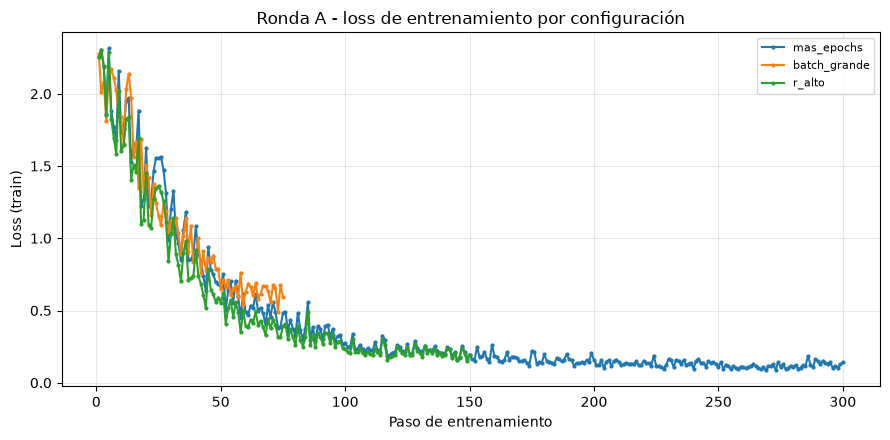

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))
for nombre, r in resultados_ronda_a.items():
    plt.plot(r["train_steps"], r["train_loss"], marker="o", markersize=2, label=nombre)
plt.xlabel("Paso de entrenamiento")
plt.ylabel("Loss (train)")
plt.title("Ronda A - loss de entrenamiento por configuración")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

tabla_ronda_a = pd.DataFrame([
    {
        "configuracion": nombre,
        "epochs": r["config"]["epochs"],
        "batch_efectivo": r["config"]["per_device_batch"] * r["config"]["grad_accum"],
        "r": r["config"]["r"],
        "lora_alpha": r["config"]["lora_alpha"],
        "warmup_steps": r["config"]["warmup_steps"],
        "weight_decay": r["config"]["weight_decay"],
        "eval_loss_final": r["eval_loss_final"],
        "tiempo_seg": round(r["tiempo_seg"], 1),
    }
    for nombre, r in resultados_ronda_a.items()
]).sort_values("eval_loss_final")

print(tabla_ronda_a.to_string(index=False))

mejor_nombre_a = tabla_ronda_a.iloc[0]["configuracion"]
mejor_config_hiperparams = next(c for c in configs_ronda_a if c["nombre"] == mejor_nombre_a)
print()
print("Mejor configuración de hiperparámetros según validation loss:", mejor_nombre_a)


configuracion  epochs  batch_efectivo  r  lora_alpha  warmup_steps  weight_decay  eval_loss_final  tiempo_seg
   mas_epochs       6               8 16          16            10          0.01         0.169966      1708.8
       r_alto       3               8 32          32            10          0.01         0.243374      6862.0
 batch_grande       3              16 16          16            10          0.01         0.699140      3484.6

Mejor configuración de hiperparámetros según validation loss: mas_epochs


## 6. Diseño experimental — ronda B (dónde aplicar LoRA)

Con la mejor combinación de hiperparámetros ya elegida, se prueba el otro eje: aplicar LoRA
solo en las proyecciones de atención (`q_proj, k_proj, v_proj, o_proj`) contra aplicarlo
también en las capas feed-forward / MLP (`gate_proj, up_proj, down_proj`). Más capas
adaptadas dan más capacidad de ajuste, pero también más parámetros entrenables y más riesgo
de sobreajuste con un dataset de este tamaño.


In [ ]:
config_solo_atencion = {**mejor_config_hiperparams, "nombre": "solo_atencion", "target_modules": ATENCION}
config_atencion_mlp = {**mejor_config_hiperparams, "nombre": "atencion_mlp", "target_modules": ATENCION_Y_MLP}

resultados_ronda_b = {}
for config in [config_solo_atencion, config_atencion_mlp]:
    print("Entrenando configuración:", config["nombre"])
    resultado = entrenar_config(config, dataset_train_texto, dataset_val_texto, tag="_b")
    print(f"  tiempo: {resultado['tiempo_seg']:.1f}s, eval_loss final: {resultado['eval_loss_final']:.4f}")
    resultados_ronda_b[config["nombre"]] = {
        k: v for k, v in resultado.items() if k not in ("modelo", "trainer")
    }
    liberar(resultado)


Entrenando configuración: solo_atencion
==((====))==  Unsloth 2026.9.10: Fast Qwen3_5 patching. Transformers: 5.17.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.14.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.8.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Current model requires 384 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
Loading weights: 100%|██████████| 723/723 [00:19<00:00, 37.00it/s] 


Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 400 | Num Epochs = 6 | Total steps = 300
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,145,728 of 4,542,411,264 (0.07% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss


In [ ]:
plt.figure(figsize=(9, 4.5))
for nombre, r in resultados_ronda_b.items():
    plt.plot(r["train_steps"], r["train_loss"], marker="o", markersize=2, label=nombre)
plt.xlabel("Paso de entrenamiento")
plt.ylabel("Loss (train)")
plt.title("Ronda B - solo atención vs. atención + MLP")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for nombre, r in resultados_ronda_b.items():
    print(nombre, "- eval_loss final:", round(r["eval_loss_final"], 4))

mejor_nombre_b = min(resultados_ronda_b, key=lambda n: resultados_ronda_b[n]["eval_loss_final"])
mejor_config_final = config_solo_atencion if mejor_nombre_b == "solo_atencion" else config_atencion_mlp
mejor_config_final = {**mejor_config_final, "nombre": "final"}
print()
print("Mejor alcance de LoRA:", mejor_nombre_b)


## 7. Entrenamiento final y evaluación contra el test set

Se reentrena una última vez con la combinación ganadora de las dos rondas anteriores. Este
modelo es el que se evalúa contra el test set.


In [ ]:
print("Configuración final elegida:")
print(mejor_config_final)

resultado_final = entrenar_config(mejor_config_final, dataset_train_texto, dataset_val_texto, tag="_final")
modelo_final = resultado_final["modelo"]
tokenizer_final = resultado_final["tokenizer"]
trainer_final = resultado_final["trainer"]

print(f"Eval loss final (validation): {resultado_final['eval_loss_final']:.4f}")


In [ ]:
metricas_test = trainer_final.evaluate(eval_dataset=dataset_test_texto)
print("Loss sobre el test set:", metricas_test["eval_loss"])


## 8. Comparación cualitativa: antes y después del fine-tuning

Para las preguntas de negocio se espera que el modelo
fine-tuned cite datos exactos del dossier (el código de producto, el horario, la política).
Para las preguntas de control, lo deseable no es necesariamente una respuesta larga: es que
el modelo no invente con seguridad algo que no está en el dossier.


In [ ]:
FastLanguageModel.for_inference(modelo_final)

print("### Preguntas de negocio ###\n")
for pregunta in PREGUNTAS_NEGOCIO:
    sin_lora = responder(modelo_final, tokenizer_final, pregunta, con_lora=False)
    con_lora = responder(modelo_final, tokenizer_final, pregunta, con_lora=True)
    print("PREGUNTA:", pregunta)
    print("SIN LoRA:", sin_lora)
    print("CON LoRA:", con_lora)
    print()

print("### Preguntas de control (generalización y olvido catastrófico) ###\n")
for pregunta in PREGUNTAS_CONTROL:
    sin_lora = responder(modelo_final, tokenizer_final, pregunta, con_lora=False)
    con_lora = responder(modelo_final, tokenizer_final, pregunta, con_lora=True)
    print("PREGUNTA:", pregunta)
    print("SIN LoRA:", sin_lora)
    print("CON LoRA:", con_lora)
    print()


Al leer las respuestas de arriba, conviene revisar en concreto:

- En la pregunta del feriado, si el modelo fine-tuned aplica la regla de "domingos y
  feriados" al 25 de diciembre, o si solo repite el horario de lunes a sábado porque
  memorizó esa frase literal.
- En la de otras sedes, si el modelo dice honestamente que hay una sola tienda, o si
  inventa una dirección con el mismo tono seguro que aprendió para el resto de respuestas.
- En la pregunta de Teoría de Juego y Organización Industrial, si la respuesta se mantiene razonable o si el modelo insiste en
  llevar todo al tono de agente de minimarket (señal de sobreajuste de tono).


## 9. Guardar el modelo

Se guardan solo los adaptadores LoRA, que es lo que realmente se entrenó: el modelo base se
puede volver a descargar de Hugging Face en cualquier momento, pero el adaptador es el
resultado propio de este notebook.


In [ ]:
RUTA_LORA = "minimarket_lora"

modelo_final.save_pretrained(RUTA_LORA)
tokenizer_final.save_pretrained(RUTA_LORA)

tamano_bytes = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, fs in os.walk(RUTA_LORA) for f in fs
)
print("Adaptadores guardados en:", RUTA_LORA)
print("Tamaño total:", round(tamano_bytes / 1e6, 1), "MB")


In [ ]:
# Opcional: modelo completo mergeado (pesos base + LoRA en un solo checkpoint),
# más pesado pero no necesita PEFT para cargarse. Descomentar si lo vas a desplegar así.

# modelo_final.save_pretrained_merged(
#     "minimarket_la_esquina_merged",
#     tokenizer_final,
#     save_method="merged_16bit",
# )
